In [9]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')

sys.path.append('../../scripts')
from data_pipeline import load_and_prepare_data, load_single_channel, test_train_split
from feature_engineering import build_state_vector
import plots, xgb_scripts, evaluate

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
def load_single_channel(data_folder, channel, cycle_range=None):
    file_path = os.path.join(data_folder, f"{channel}.csv")
    df = pd.read_csv(file_path).dropna()

    if "#NAME?" in df.columns: df = df.rename(columns={"#NAME?": "-Im(Z)/Ohm"})

    df["channel"] = channel  

    if cycle_range is not None:
        lo, hi = cycle_range
        df = df[df['cycle number'].between(lo, hi)].copy()
    else:
        max_cycle = df['cycle number'].max()
        df = df[(df['cycle number'] > 0) & (df['cycle number'] < max_cycle)].copy()

    return df

In [11]:
for folder in ["../../data/03-22-24", "../../data/04-03-24"]:
  print("\n" + "="*80)
  print(f"DATA FOLDER: {folder}")
  print("="*80)
  
  all_channels = sorted([f[:-4] for f in os.listdir(folder) if f.endswith('.csv')])

  for channel in all_channels:
    print(f"\n{'':-^70}")
    print(f"    Channel: {channel}")
    print(f"{'':-^70}")
    
    df = load_single_channel(data_folder=folder, channel=channel)
    
    df_ns1 = df.dropna().query("`freq/Hz` > 0.2 and `freq/Hz` <= 20000 and Ns == 1")
    unique_freqs_ns1 = sorted(df_ns1['freq/Hz'].unique())
    print(f"    [Ns=1] Found {len(unique_freqs_ns1)} unique frequencies.")
    print(f"           Frequencies: {unique_freqs_ns1}")
    
    df_ns6 = df.dropna().query("`freq/Hz` > 0.2 and `freq/Hz` <= 20000 and Ns == 6")
    unique_freqs_ns6 = sorted(df_ns6['freq/Hz'].unique())
    print(f"    [Ns=6] Found {len(unique_freqs_ns6)} unique frequencies.")
    print(f"           Frequencies: {unique_freqs_ns6}")


DATA FOLDER: ../../data/03-22-24

----------------------------------------------------------------------
    Channel: B1
----------------------------------------------------------------------
    [Ns=1] Found 37 unique frequencies.
           Frequencies: [0.254, 0.34, 0.456, 0.612, 0.822, 1.1, 1.48, 1.99, 2.66, 3.57, 4.8, 6.43, 8.64, 11.6, 15.5, 20.9, 28.0, 37.5, 50.3, 67.6, 90.6, 122.0, 163.0, 219.0, 294.0, 394.0, 529.0, 710.0, 952.0, 1280.0, 1710.0, 2300.0, 3090.0, 4140.0, 5560.0, 7450.0, 10000.0]
    [Ns=6] Found 33 unique frequencies.
           Frequencies: [0.999, 1.33, 1.78, 2.37, 3.16, 4.22, 5.62, 7.5, 10.0, 13.3, 17.8, 23.7, 31.6, 42.2, 56.2, 75.0, 102.0, 135.0, 178.0, 237.0, 316.0, 422.0, 564.0, 750.0, 1000.0, 1330.0, 1780.0, 2370.0, 3160.0, 4220.0, 5620.0, 7500.0, 10000.0]

----------------------------------------------------------------------
    Channel: B2
----------------------------------------------------------------------
    [Ns=1] Found 37 unique frequencies.
    

In [12]:
import joblib
import shap
from data_pipeline import load_and_prepare_data

In [13]:
# Load saved models
xgb_loso = joblib.load("../../models/xgb_LOSO.pkl")
xgb_temporal = joblib.load("../../models/xgb_temporal.pkl")

print("Models loaded successfully")
print(f"LOSO model: {len(xgb_loso)} ensemble models")
print(f"Temporal model: {len(xgb_temporal)} ensemble models")

Models loaded successfully
LOSO model: 5 ensemble models
Temporal model: 5 ensemble models


In [14]:
# Load corresponding training data
X_train_loso, X_test_loso, y_train_loso, y_test_loso = load_and_prepare_data(
    data_folder="../../data/04-03-24"
)

X_train_temporal, X_test_temporal, y_train_temporal, y_test_temporal = load_and_prepare_data(
    data_folder="../../data/04-03-24",
    method="temporal"
)

print(f"LOSO data: X_train {X_train_loso.shape}, X_test {X_test_loso.shape}")
print(f"Temporal data: X_train {X_train_temporal.shape}, X_test {X_test_temporal.shape}")

X_train: (1632, 66), y_train: (1632,)
X_test: (566, 66), y_test: (566,)
Train capacity range: 84.8 - 4040.0 mAh
Test capacity range: 76.1 - 4030.0 mAh
X_train: (1315, 66), y_train: (1315,)
X_test: (883, 66), y_test: (883,)
Train capacity range: 1600.0 - 4040.0 mAh
Test capacity range: 76.1 - 3610.0 mAh
LOSO data: X_train (1632, 66), X_test (566, 66)
Temporal data: X_train (1315, 66), X_test (883, 66)


In [15]:
# XGBoost built-in feature importance for LOSO model
def analyze_xgb_feature_importance(models, model_name, X_train, top_k=20):
    # Average feature importance across ensemble
    feature_importances = np.zeros(X_train.shape[1])
    
    for model in models:
        importance = model.feature_importances_
        feature_importances += importance
    
    feature_importances /= len(models)
    
    # Get top features
    top_indices = np.argsort(feature_importances)[::-1][:top_k]
    top_importances = feature_importances[top_indices]
    
    print(f"\n{model_name} - Top {top_k} Features (XGBoost importance):")
    for i, (idx, importance) in enumerate(zip(top_indices, top_importances)):
        print(f"{i+1:2d}. Feature {idx:2d}: {importance:.4f}")
    
    return top_indices, top_importances

# Analyze both models
loso_indices, loso_importance = analyze_xgb_feature_importance(xgb_loso, "LOSO Model", X_train_loso)
temporal_indices, temporal_importance = analyze_xgb_feature_importance(xgb_temporal, "Temporal Model", X_train_temporal)


LOSO Model - Top 20 Features (XGBoost importance):
 1. Feature 50: 0.1891
 2. Feature 45: 0.1730
 3. Feature 46: 0.1165
 4. Feature 47: 0.0762
 5. Feature 51: 0.0614
 6. Feature 43: 0.0574
 7. Feature 48: 0.0548
 8. Feature 52: 0.0305
 9. Feature  3: 0.0289
10. Feature  2: 0.0267
11. Feature 40: 0.0240
12. Feature 56: 0.0197
13. Feature 49: 0.0193
14. Feature 53: 0.0191
15. Feature 41: 0.0148
16. Feature  4: 0.0114
17. Feature 44: 0.0114
18. Feature 42: 0.0095
19. Feature 57: 0.0091
20. Feature  7: 0.0084

Temporal Model - Top 20 Features (XGBoost importance):
 1. Feature 31: 0.2669
 2. Feature 30: 0.2507
 3. Feature 29: 0.1467
 4. Feature 27: 0.0863
 5. Feature 28: 0.0710
 6. Feature 43: 0.0289
 7. Feature 26: 0.0202
 8. Feature 44: 0.0198
 9. Feature 32: 0.0187
10. Feature 40: 0.0156
11. Feature 23: 0.0149
12. Feature 41: 0.0111
13. Feature 42: 0.0109
14. Feature 21: 0.0066
15. Feature 24: 0.0052
16. Feature  1: 0.0047
17. Feature 39: 0.0039
18. Feature  3: 0.0027
19. Feature  2: 0.

In [16]:
# SHAP analysis for LOSO model
def analyze_shap_importance(models, X_train, model_name, sample_size=100):
    # Use first model for SHAP analysis (representative of ensemble)
    model = models[0]
    
    # Sample data for faster computation
    X_sample = X_train[:sample_size] if len(X_train) > sample_size else X_train
    
    # Create explainer and get SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    
    # Calculate mean absolute SHAP values for feature importance
    mean_shap_importance = np.mean(np.abs(shap_values), axis=0)
    
    # Get top features
    top_indices = np.argsort(mean_shap_importance)[::-1][:20]
    top_shap_values = mean_shap_importance[top_indices]
    
    print(f"\n{model_name} - Top 20 Features (SHAP importance):")
    for i, (idx, shap_val) in enumerate(zip(top_indices, top_shap_values)):
        print(f"{i+1:2d}. Feature {idx:2d}: {shap_val:.4f}")
    
    return shap_values, mean_shap_importance, top_indices

# Analyze SHAP for both models
print("Computing SHAP values for LOSO model...")
shap_loso, shap_importance_loso, shap_top_loso = analyze_shap_importance(xgb_loso, X_train_loso, "LOSO Model")

print("\nComputing SHAP values for Temporal model...")
shap_temporal, shap_importance_temporal, shap_top_temporal = analyze_shap_importance(xgb_temporal, X_train_temporal, "Temporal Model")

Computing SHAP values for LOSO model...

LOSO Model - Top 20 Features (SHAP importance):
 1. Feature  3: 82.2326
 2. Feature  1: 65.4853
 3. Feature 43: 63.5076
 4. Feature  2: 49.6315
 5. Feature 48: 43.1515
 6. Feature 56: 32.7457
 7. Feature 46: 29.3066
 8. Feature 45: 27.7013
 9. Feature 52: 26.6057
10. Feature 44: 26.4614
11. Feature 51: 24.7903
12. Feature  4: 20.6067
13. Feature 50: 19.2939
14. Feature 40: 17.7874
15. Feature  0: 14.8283
16. Feature 39: 14.6822
17. Feature 41: 11.2723
18. Feature 49: 11.2414
19. Feature 42: 10.2107
20. Feature 57: 8.6854

Computing SHAP values for Temporal model...

Temporal Model - Top 20 Features (SHAP importance):
 1. Feature 43: 50.3326
 2. Feature 40: 26.7172
 3. Feature 30: 23.5080
 4. Feature 29: 21.1352
 5. Feature 44: 20.9421
 6. Feature 41: 19.8679
 7. Feature 31: 18.4929
 8. Feature 42: 15.0013
 9. Feature 28: 14.8116
10. Feature 27: 14.4514
11. Feature  0: 11.2384
12. Feature 32: 8.7608
13. Feature  2: 6.7830
14. Feature 39: 5.3129
1

In [17]:
# Compare feature importance between models
def compare_feature_importance(loso_indices, temporal_indices, loso_shap_indices, temporal_shap_indices):
    print("\nFeature Importance Comparison:")
    print("=" * 50)
    
    # XGBoost importance comparison
    print("\nXGBoost Feature Importance - Top 10 overlap:")
    loso_top10 = set(loso_indices[:10])
    temporal_top10 = set(temporal_indices[:10])
    overlap_xgb = loso_top10.intersection(temporal_top10)
    print(f"Common features: {sorted(overlap_xgb)}")
    print(f"Overlap: {len(overlap_xgb)}/10 features")
    
    # SHAP importance comparison
    print("\nSHAP Feature Importance - Top 10 overlap:")
    loso_shap_top10 = set(loso_shap_indices[:10])
    temporal_shap_top10 = set(temporal_shap_indices[:10])
    overlap_shap = loso_shap_top10.intersection(temporal_shap_top10)
    print(f"Common features: {sorted(overlap_shap)}")
    print(f"Overlap: {len(overlap_shap)}/10 features")
    
    # Most consistent features across all methods
    all_important = loso_top10.union(temporal_top10).union(loso_shap_top10).union(temporal_shap_top10)
    consistent_features = []
    
    for feature in all_important:
        count = 0
        if feature in loso_top10: count += 1
        if feature in temporal_top10: count += 1
        if feature in loso_shap_top10: count += 1
        if feature in temporal_shap_top10: count += 1
        if count >= 3:
            consistent_features.append(feature)
    
    print(f"\nMost consistent features (appear in 3+ rankings): {sorted(consistent_features)}")

compare_feature_importance(loso_indices, temporal_indices, shap_top_loso, shap_top_temporal)


Feature Importance Comparison:

XGBoost Feature Importance - Top 10 overlap:
Common features: [43]
Overlap: 1/10 features

SHAP Feature Importance - Top 10 overlap:
Common features: [43, 44]
Overlap: 2/10 features

Most consistent features (appear in 3+ rankings): [43, 44]


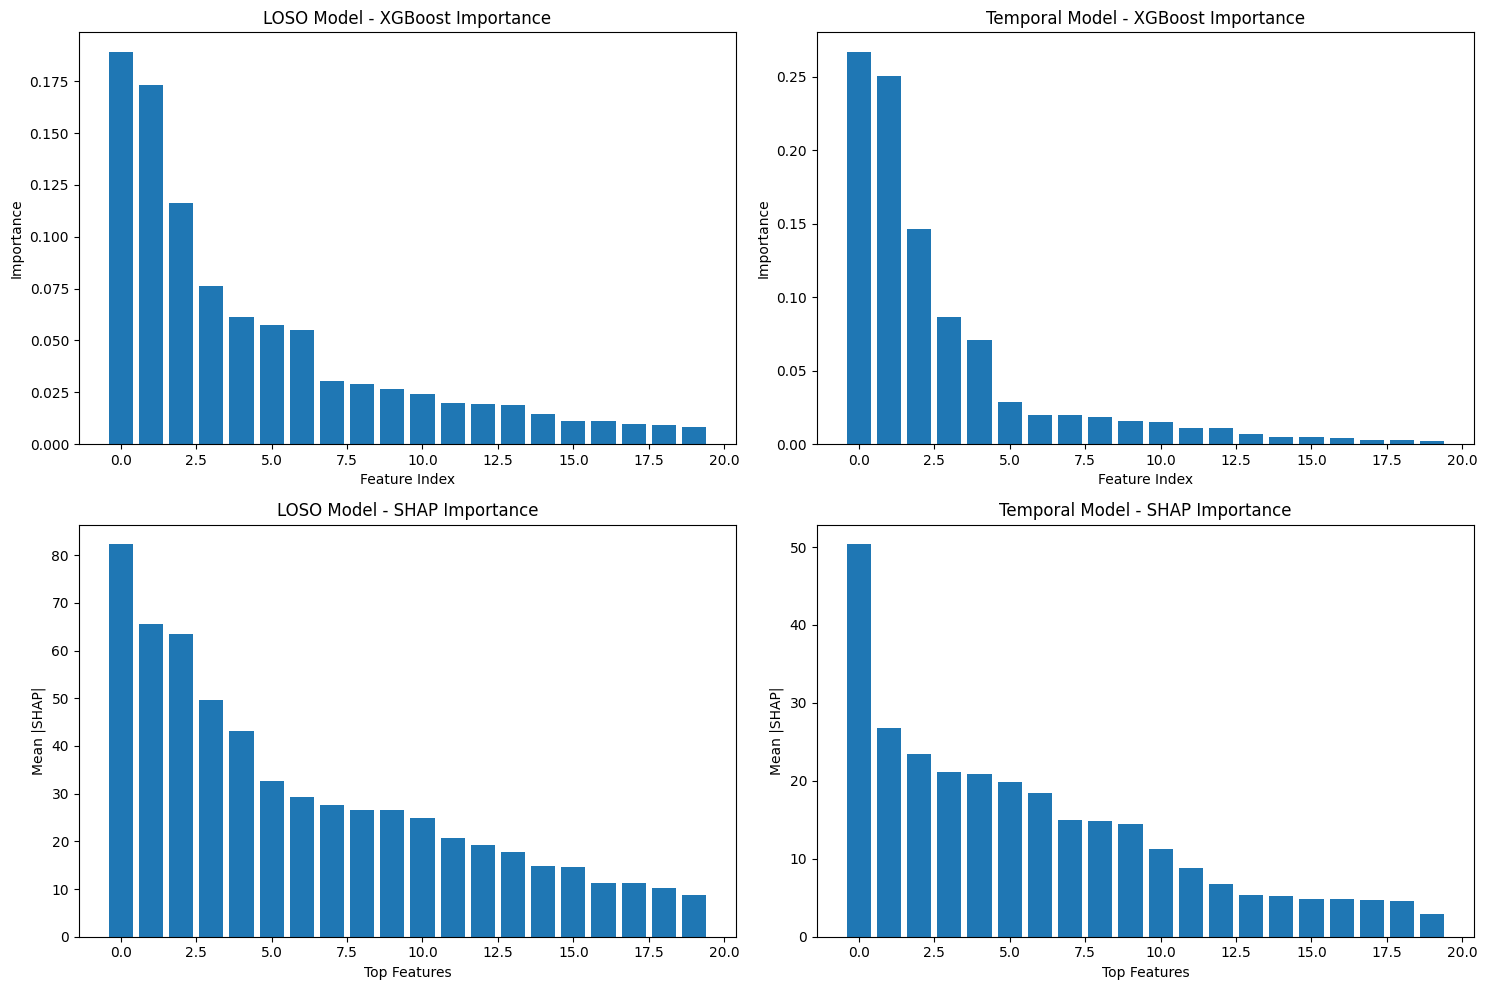

In [18]:
# Visualize feature importance
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# XGBoost importance plots
axes[0,0].bar(range(len(loso_importance)), loso_importance)
axes[0,0].set_title('LOSO Model - XGBoost Importance')
axes[0,0].set_xlabel('Feature Index')
axes[0,0].set_ylabel('Importance')

axes[0,1].bar(range(len(temporal_importance)), temporal_importance)
axes[0,1].set_title('Temporal Model - XGBoost Importance')
axes[0,1].set_xlabel('Feature Index')
axes[0,1].set_ylabel('Importance')

# SHAP importance plots
axes[1,0].bar(range(len(shap_importance_loso[shap_top_loso])), shap_importance_loso[shap_top_loso])
axes[1,0].set_title('LOSO Model - SHAP Importance')
axes[1,0].set_xlabel('Top Features')
axes[1,0].set_ylabel('Mean |SHAP|')

axes[1,1].bar(range(len(shap_importance_temporal[shap_top_temporal])), shap_importance_temporal[shap_top_temporal])
axes[1,1].set_title('Temporal Model - SHAP Importance')
axes[1,1].set_xlabel('Top Features')
axes[1,1].set_ylabel('Mean |SHAP|')

plt.tight_layout()
plt.show()

In [19]:
# Map feature indices to frequencies
def map_features_to_frequencies(feature_indices, top_k=10):
    # Load a sample to get frequency mapping
    sample_df = load_single_channel("../../data/04-03-24", "A1")
    df_filtered = sample_df.dropna().query("`freq/Hz` > 0.2 and `freq/Hz` <= 20000 and Ns == 6")
    frequencies = sorted(df_filtered['freq/Hz'].unique())
    
    print(f"Feature to Frequency Mapping (Top {top_k}):")
    print("Feature Index -> [Frequency (Hz), Component]")
    print("-" * 50)
    
    frequency_importance = {}
    
    for i, feat_idx in enumerate(feature_indices[:top_k]):
        freq_idx = feat_idx // 2  # Each frequency has 2 features (Re, Im)
        component = "Re" if feat_idx % 2 == 0 else "Im"
        
        if freq_idx < len(frequencies):
            freq = frequencies[freq_idx]
            print(f"Feature {feat_idx:2d} -> [{freq:8.3f} Hz, {component}]")
            
            # Track frequency importance
            if freq not in frequency_importance:
                frequency_importance[freq] = 0
            frequency_importance[freq] += 1
        else:
            print(f"Feature {feat_idx:2d} -> [Unknown frequency]")
    
    return frequency_importance

print("LOSO Model - Most Important Frequencies:")
loso_freq_importance = map_features_to_frequencies(loso_indices)

print("\nTemporal Model - Most Important Frequencies:")
temporal_freq_importance = map_features_to_frequencies(temporal_indices)

print("\nSHAP LOSO Model - Most Important Frequencies:")
shap_loso_freq_importance = map_features_to_frequencies(shap_top_loso)

print("\nSHAP Temporal Model - Most Important Frequencies:")
shap_temporal_freq_importance = map_features_to_frequencies(shap_top_temporal)

LOSO Model - Most Important Frequencies:
Feature to Frequency Mapping (Top 10):
Feature Index -> [Frequency (Hz), Component]
--------------------------------------------------
Feature 50 -> [1330.000 Hz, Re]
Feature 45 -> [ 564.000 Hz, Im]
Feature 46 -> [ 750.000 Hz, Re]
Feature 47 -> [ 750.000 Hz, Im]
Feature 51 -> [1330.000 Hz, Im]
Feature 43 -> [ 422.000 Hz, Im]
Feature 48 -> [1000.000 Hz, Re]
Feature 52 -> [1780.000 Hz, Re]
Feature  3 -> [   1.330 Hz, Im]
Feature  2 -> [   1.330 Hz, Re]

Temporal Model - Most Important Frequencies:
Feature to Frequency Mapping (Top 10):
Feature Index -> [Frequency (Hz), Component]
--------------------------------------------------
Feature 31 -> [  75.000 Hz, Im]
Feature 30 -> [  75.000 Hz, Re]
Feature 29 -> [  56.200 Hz, Im]
Feature 27 -> [  42.200 Hz, Im]
Feature 28 -> [  56.200 Hz, Re]
Feature 43 -> [ 422.000 Hz, Im]
Feature 26 -> [  42.200 Hz, Re]
Feature 44 -> [ 564.000 Hz, Re]
Feature 32 -> [ 102.000 Hz, Re]
Feature 40 -> [ 316.000 Hz, Re]

SH

In [20]:
# Summary of most consistently important frequencies
def summarize_important_frequencies():
    # Combine all frequency importance data
    all_freq_counts = {}
    
    for freq_dict in [loso_freq_importance, temporal_freq_importance, 
                      shap_loso_freq_importance, shap_temporal_freq_importance]:
        for freq, count in freq_dict.items():
            if freq not in all_freq_counts:
                all_freq_counts[freq] = 0
            all_freq_counts[freq] += count
    
    # Sort by total importance across all methods
    sorted_freqs = sorted(all_freq_counts.items(), key=lambda x: x[1], reverse=True)
    
    print("\nMost Consistently Important Frequencies Across All Models:")
    print("Frequency (Hz) | Total Mentions | EIS Region")
    print("-" * 55)
    
    for freq, count in sorted_freqs[:15]:
        # Classify EIS frequency regions
        if freq > 10000:
            region = "High Freq (Resistance)"
        elif freq > 1000:
            region = "Mid-High (SEI)"
        elif freq > 100:
            region = "Mid (Charge Transfer)"
        elif freq > 1:
            region = "Low (Diffusion)"
        else:
            region = "Very Low (Warburg)"
            
        print(f"{freq:10.3f}    |      {count:2d}       | {region}")

summarize_important_frequencies()


Most Consistently Important Frequencies Across All Models:
Frequency (Hz) | Total Mentions | EIS Region
-------------------------------------------------------
   564.000    |       5       | Mid (Charge Transfer)
   422.000    |       5       | Mid (Charge Transfer)
     1.330    |       4       | Low (Diffusion)
    75.000    |       4       | Low (Diffusion)
    56.200    |       4       | Low (Diffusion)
   750.000    |       3       | Mid (Charge Transfer)
    42.200    |       3       | Low (Diffusion)
   316.000    |       3       | Mid (Charge Transfer)
  1330.000    |       2       | Mid-High (SEI)
  1000.000    |       2       | Mid (Charge Transfer)
  1780.000    |       2       | Mid-High (SEI)
   102.000    |       1       | Mid (Charge Transfer)
     0.999    |       1       | Very Low (Warburg)
  3160.000    |       1       | Mid-High (SEI)


In [21]:
# Analyze frequency patterns in more detail
def analyze_frequency_patterns():
    # Get all frequencies used
    sample_df = load_single_channel("../../data/04-03-24", "A1")
    df_filtered = sample_df.dropna().query("`freq/Hz` > 0.2 and `freq/Hz` <= 20000 and Ns == 6")
    all_frequencies = sorted(df_filtered['freq/Hz'].unique())
    
    # Combine all important feature indices
    all_important_features = set()
    all_important_features.update(loso_indices[:20])
    all_important_features.update(temporal_indices[:20])
    all_important_features.update(shap_top_loso[:20])
    all_important_features.update(shap_top_temporal[:20])
    
    # Map to frequencies and analyze distribution
    freq_mentions = {}
    for feat_idx in all_important_features:
        freq_idx = feat_idx // 2
        if freq_idx < len(all_frequencies):
            freq = all_frequencies[freq_idx]
            freq_mentions[freq] = freq_mentions.get(freq, 0) + 1
    
    # Categorize by frequency ranges
    freq_ranges = {
        'Very Low (0.2-1 Hz)': [],
        'Low (1-10 Hz)': [],
        'Mid-Low (10-100 Hz)': [],
        'Mid (100-1000 Hz)': [],
        'Mid-High (1-10 kHz)': [],
        'High (10+ kHz)': []
    }
    
    for freq, mentions in freq_mentions.items():
        if freq < 1:
            freq_ranges['Very Low (0.2-1 Hz)'].append((freq, mentions))
        elif freq < 10:
            freq_ranges['Low (1-10 Hz)'].append((freq, mentions))
        elif freq < 100:
            freq_ranges['Mid-Low (10-100 Hz)'].append((freq, mentions))
        elif freq < 1000:
            freq_ranges['Mid (100-1000 Hz)'].append((freq, mentions))
        elif freq < 10000:
            freq_ranges['Mid-High (1-10 kHz)'].append((freq, mentions))
        else:
            freq_ranges['High (10+ kHz)'].append((freq, mentions))
    
    print("\nFrequency Range Analysis:")
    print("=" * 60)
    
    total_mentions = 0
    for range_name, freqs in freq_ranges.items():
        range_mentions = sum(mentions for _, mentions in freqs)
        total_mentions += range_mentions
        
        print(f"\n{range_name}:")
        print(f"  Frequencies: {len(freqs)} | Total importance: {range_mentions}")
        
        if freqs:
            # Show top frequencies in this range
            sorted_freqs = sorted(freqs, key=lambda x: x[1], reverse=True)[:3]
            for freq, mentions in sorted_freqs:
                print(f"    {freq:8.3f} Hz: {mentions} mentions")
    
    # Calculate percentage by range
    print(f"\nImportance Distribution:")
    for range_name, freqs in freq_ranges.items():
        range_mentions = sum(mentions for _, mentions in freqs)
        percentage = (range_mentions / total_mentions * 100) if total_mentions > 0 else 0
        print(f"  {range_name}: {percentage:.1f}%")
    
    print(f"\nPhysical Interpretation:")
    print("Low frequencies (0.2-10 Hz) capture:")
    print("  - Lithium diffusion in electrodes")
    print("  - Mass transport limitations") 
    print("  - Long-term degradation processes")
    print("  - Capacity fade mechanisms")
    print("\nThis suggests your model is learning physically meaningful")
    print("degradation signatures rather than just noise!")

analyze_frequency_patterns()


Frequency Range Analysis:

Very Low (0.2-1 Hz):
  Frequencies: 1 | Total importance: 2
       0.999 Hz: 2 mentions

Low (1-10 Hz):
  Frequencies: 3 | Total importance: 4
       1.330 Hz: 2 mentions
       1.780 Hz: 1 mentions
       2.370 Hz: 1 mentions

Mid-Low (10-100 Hz):
  Frequencies: 6 | Total importance: 9
      42.200 Hz: 2 mentions
      56.200 Hz: 2 mentions
      75.000 Hz: 2 mentions

Mid (100-1000 Hz):
  Frequencies: 7 | Total importance: 12
     102.000 Hz: 2 mentions
     316.000 Hz: 2 mentions
     422.000 Hz: 2 mentions

Mid-High (1-10 kHz):
  Frequencies: 4 | Total importance: 8
    1000.000 Hz: 2 mentions
    1330.000 Hz: 2 mentions
    1780.000 Hz: 2 mentions

High (10+ kHz):
  Frequencies: 0 | Total importance: 0

Importance Distribution:
  Very Low (0.2-1 Hz): 5.7%
  Low (1-10 Hz): 11.4%
  Mid-Low (10-100 Hz): 25.7%
  Mid (100-1000 Hz): 34.3%
  Mid-High (1-10 kHz): 22.9%
  High (10+ kHz): 0.0%

Physical Interpretation:
Low frequencies (0.2-10 Hz) capture:
  - Lit